In [1]:
!pwd

/home/kyoda/Proyectos/Universidad/Especializacion/big-data-postgraduate-bpineda/kit/Notebooks/Exercises


In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import numpy as np

gdf_municipios = gpd.read_file("../../data/raw/MGN2025_MPIO_GRAFICO/MGN_ADM_MPIO_GRAFICO.shp")


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

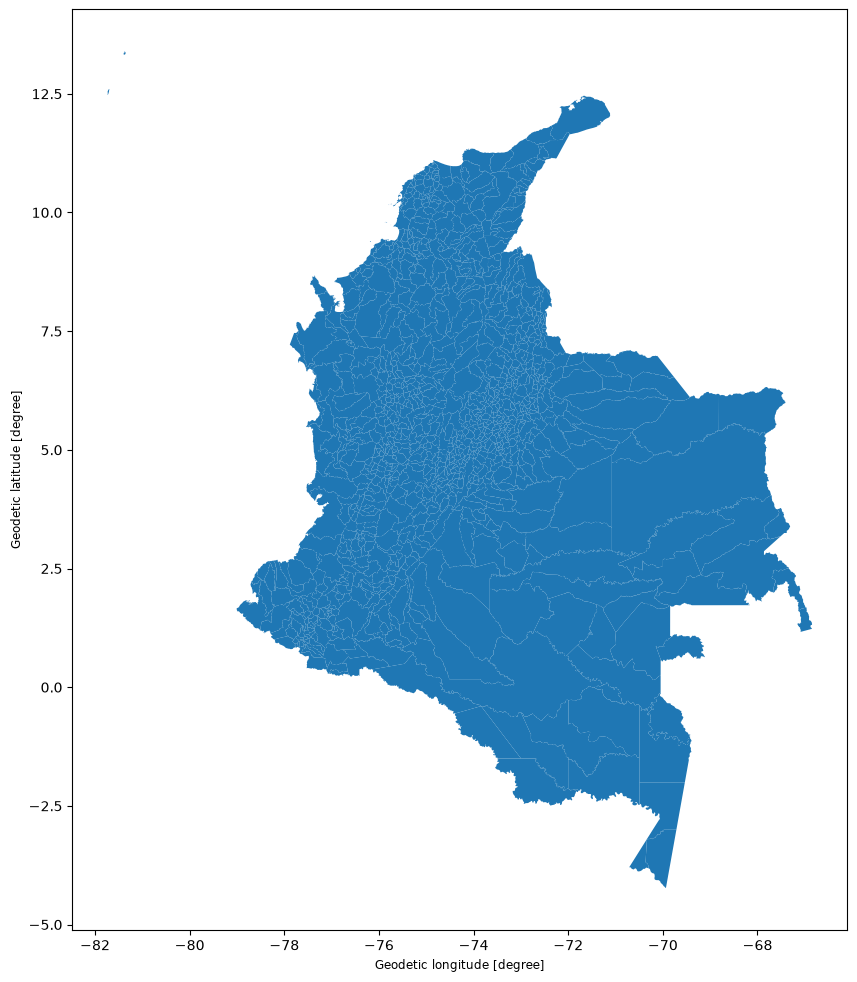

In [3]:
gdf_municipios.plot(figsize=(10,15))

In [4]:
pd.set_option('display.max_columns',None)
gdf_municipios.head(10)

,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.741484,2025,1.035380,0.030608,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,506.959782,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05,004,05004,ANTIOQUIA,ABRIAQUÍ,1912,MUNICIPIO,296.974188,2025,0.810667,0.024253,"POLYGON ((-76.09047 6.74542, -76.09066 6.74548..."
3,05,021,05021,ANTIOQUIA,ALEJANDRÍA,Decreto departamental 304 de 1907,MUNICIPIO,128.856431,2024,0.705200,0.010535,"POLYGON ((-75.0332 6.41586, -75.03313 6.41585,..."
4,05,030,05030,ANTIOQUIA,AMAGÁ,1912,MUNICIPIO,84.117145,2024,0.445533,0.006867,"POLYGON ((-75.67587 6.08561, -75.6754 6.08491,..."
5,05,031,05031,ANTIOQUIA,AMALFI,1843,MUNICIPIO,1208.346188,2025,2.058482,0.098921,"POLYGON ((-74.91364 7.28807, -74.91361 7.28789..."
6,05,034,05034,ANTIOQUIA,ANDES,1853,MUNICIPIO,402.450599,2024,1.146984,0.032817,"POLYGON ((-75.86822 5.75753, -75.86827 5.75673..."
7,05,036,05036,ANTIOQUIA,ANGELÓPOLIS,Ordenanza 16 del 12 de julio de 1896,MUNICIPIO,81.861768,2024,0.427496,0.006683,"POLYGON ((-75.69149 6.1932, -75.6908 6.19319, ..."
8,05,038,05038,ANTIOQUIA,ANGOSTURA,1821,MUNICIPIO,338.361850,2024,0.916465,0.027680,"POLYGON ((-75.27173 6.97094, -75.27164 6.9709,..."
9,05,040,05040,ANTIOQUIA,ANORÍ,1821,MUNICIPIO,1412.956957,2024,1.847644,0.115706,"POLYGON ((-74.90935 7.45001, -74.9091 7.45001,..."


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

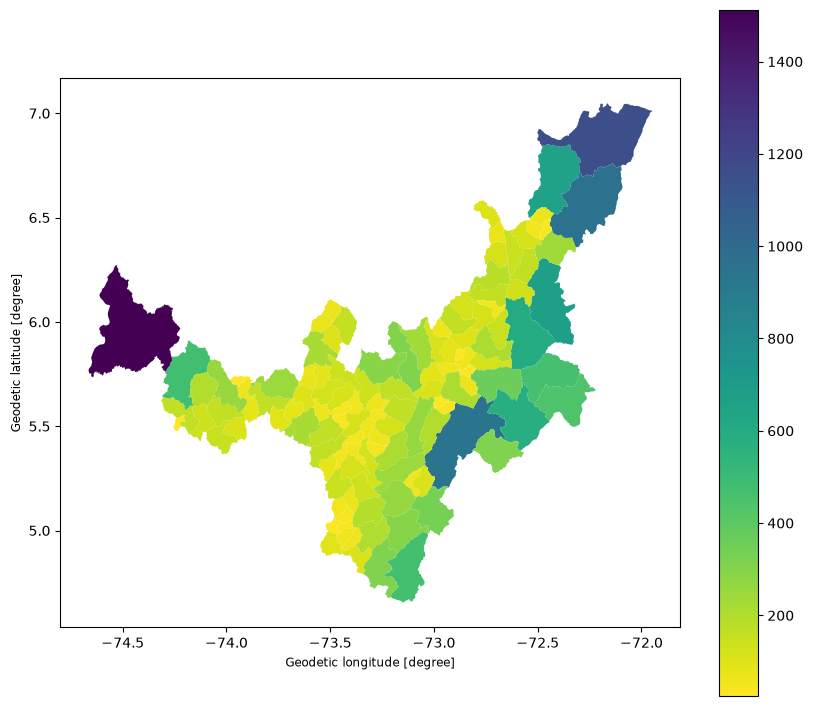

In [5]:
#graficar poligonos geoespaciales
municipios_boyaca =gdf_municipios[gdf_municipios['dpto_cnmbr'] == 'BOYACÁ']
municipios_boyaca.plot(figsize=(10,10), cmap= "viridis_r", column="mpio_narea", legend=True)

In [6]:
#joins espaciales
chiq = gdf_municipios[gdf_municipios['mpio_cnmbr'] == 'CHIQUINQUIRÁ']
municipios_antioquia = gdf_municipios[gdf_municipios['dpto_cnmbr'] == 'ANTIOQUIA']
result = gpd.sjoin(chiq, municipios_antioquia, how= 'inner',predicate="within")
display(result)

,dpto_ccdgo_left,mpio_ccdgo_left,mpio_cdpmp_left,dpto_cnmbr_left,mpio_cnmbr_left,mpio_crslc_left,mpio_tipo_left,mpio_narea_left,mpio_nano_left,shape_Leng_left,shape_Area_left,geometry,index_right,dpto_ccdgo_right,mpio_ccdgo_right,mpio_cdpmp_right,dpto_cnmbr_right,mpio_cnmbr_right,mpio_crslc_right,mpio_tipo_right,mpio_narea_right,mpio_nano_right,shape_Leng_right,shape_Area_right


In [7]:
df_eva = pd.read_csv("../../data/raw/eva.csv")
df_divipola = pd.read_csv("../../data/raw/divipola.csv")
print("=============================dvivipola=======================")
df_divipola.info()
print("=============================eva=======================")
df_eva.info()

=============================dvivipola=======================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Código Departamento                              1122 non-null   int64 
 1   Nombre Departamento                              1122 non-null   object
 2   Código Municipio                                 1122 non-null   int64 
 3   Nombre Municipio                                 1122 non-null   object
 4   Tipo: Municipio / Isla / Área no municipalizada  1122 non-null   object
 5   longitud                                         1122 non-null   object
 6   Latitud                                          1122 non-null   object
dtypes: int64(2), object(5)
memory usage: 61.5+ KB
=============================eva=======================
<class 'pandas.core.frame.DataFr

In [8]:
print("=============================divipola=======================")
display(df_divipola.sort_values(by=['Código Departamento'], ascending= True)['Código Departamento'].drop_duplicates())
print("=============================eva=======================")
display(df_eva.sort_values(by=['Código Dane departamento'], ascending= True)['Código Dane departamento'].drop_duplicates())

=============================divipola=======================


0        5
128      8
148     11
165     13
257     15
323     17
359     18
391     19
411     20
437     23
491     25
583     27
627     41
655     44
659     47
689     50
724     52
798     54
831     63
832     66
858     68
933     70
987     73
1031    76
1054    81
1070    85
1074    86
1087    88
1090    91
1102    94
1110    95
1112    97
1120    99
Name: Código Departamento, dtype: int64

=============================eva=======================


10269      5
17196      8
21324     13
34724     15
43191     17
45513     18
46106     19
53608     20
61987     23
72404     25
79875     27
92723     41
95134     44
99406     47
103689    50
111505    52
120082    54
123792    63
125790    66
135167    68
141834    70
149614    73
160177    76
160991    81
163331    85
164332    86
164957    88
165298    91
165548    94
165979    95
166155    97
166684    99
Name: Código Dane departamento, dtype: int64

In [ ]:
gdf_municipios['dpto_ccdgo'] = gdf_municipios['dpto_ccdgo'].astype(int)
df_divipola['Código Departamento'] = df_divipola['Código Departamento'].astype(int)
df_eva['Código Dane departamento'] = df_eva['Código Dane departamento'].astype(int)
display(len(gdf_municipios['dpto_ccdgo'].sort_values().unique()))
display(len(df_divipola['Código Departamento'].sort_values().unique()))
display(len(df_eva['Código Dane departamento'].sort_values().unique()))

merged_df = pd.merge(right=df_eva,left=df_divipola,how='inner',left_on=['Código Dane departamento'], right_on=['Código Departamento'],indicator=True)
display(merged_df[merged_df['_merge']!='both'])

res = np.nonzero(np.isin(df_divipola['Código Departamento'].sort_values().unique(),df_eva['Código Dane departamento'].sort_values().unique()))

33

33

32

,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Grupo cultivo,Subgrupo,Cultivo,Desagregación cultivo,Año,Periodo,Área sembrada,Área cosechada,Producción,Rendimiento,Ciclo del cultivo,Estado físico del cultivo,Código del cultivo,Nombre científico del cultivo,Código Departamento,Nombre Departamento,Código Municipio,Nombre Municipio,Tipo: Municipio / Isla / Área no municipalizada,longitud,Latitud,_merge


In [14]:
print(df_divipola['Código Departamento'].sort_values().unique())
print(df_eva['Código Dane departamento'].sort_values().unique())

[ 5  8 11 13 15 17 18 19 20 23 25 27 41 44 47 50 52 54 63 66 68 70 73 76
 81 85 86 88 91 94 95 97 99]
[ 5  8 13 15 17 18 19 20 23 25 27 41 44 47 50 52 54 63 66 68 70 73 76 81
 85 86 88 91 94 95 97 99]
